# Validación teórica: Flooding vs Kademlia
**TP Final SOR2 — Tema D1**

Este notebook integra los resultados experimentales con las predicciones teóricas del curso:
- Complejidad de búsqueda: O(N) flooding vs O(log N) Kademlia  
- Tiempos de distribución: Tcs y Tp2p (fórmulas de la Unidad 9)  
- Análisis de robustez bajo churn (5%, 10%, 20%)  
- Documentación de divergencias teoría-simulación


In [1]:
import sys
from pathlib import Path

# Make sure project root is in path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy import stats

# Import our analysis helpers
from analysis.statistical_analysis import (
    calculate_tcs, calculate_tp2p, build_theory_table,
    build_comparative_table, fit_flooding_scaling, fit_kademlia_scaling,
    _load_all_flooding, _load_all_kademlia,
)
from analysis.plot_results import load_experiment_summaries, load_churn_data

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.2)

DATA_DIR = PROJECT_ROOT / 'data'
FIG_DIR  = PROJECT_ROOT / 'informe' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Data dir exists:', DATA_DIR.exists())

Project root: C:\Users\User\Desktop\Kademlia vs Flooding\Kademlia-vs-Flooding
Data dir exists: True


## 1. Carga de datos experimentales

In [2]:
flood_raw = _load_all_flooding(DATA_DIR)
kad_raw   = _load_all_kademlia(DATA_DIR)
flood_raw['success'] = flood_raw['success'].astype(bool)
kad_raw['success']   = kad_raw['success'].astype(bool)

print(f'Flooding rows: {len(flood_raw):,}')
print(f'Kademlia rows: {len(kad_raw):,}')
print('\nFlooding configs:', sorted(flood_raw[['N','K']].drop_duplicates().values.tolist()))
print('Kademlia configs:', sorted(kad_raw[['N','B']].drop_duplicates().values.tolist()))

Flooding rows: 2,000
Kademlia rows: 1,400

Flooding configs: [[10, 5], [10, 10], [50, 5], [50, 10], [50, 20], [100, 5], [100, 10], [100, 20], [500, 5], [500, 10], [500, 20], [1000, 5], [1000, 10], [1000, 20], [5000, 5], [5000, 10], [5000, 20], [15000, 5], [15000, 10], [15000, 20]]
Kademlia configs: [[10, 8], [10, 16], [50, 8], [50, 16], [100, 8], [100, 16], [500, 8], [500, 16], [1000, 8], [1000, 16], [5000, 8], [5000, 16], [15000, 8], [15000, 16]]


## 2. Gráfico 1: Mensajes vs N (log-log)

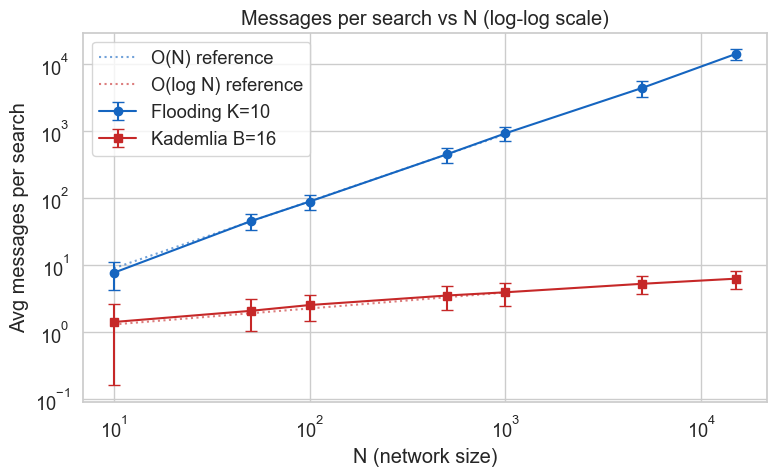

In [3]:
f10 = flood_raw[flood_raw['K'] == 10].groupby('N')['messages'].agg(['mean','std']).reset_index()
k16 = kad_raw[kad_raw['B'] == 16].groupby('N')['messages'].agg(['mean','std']).reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

ax.errorbar(f10['N'], f10['mean'], yerr=f10['std'],
            fmt='o-', color='#1565C0', capsize=4, label='Flooding K=10')
ax.errorbar(k16['N'], k16['mean'], yerr=k16['std'],
            fmt='s-', color='#C62828', capsize=4, label='Kademlia B=16')

# Reference lines
ns = np.array([10, 1000])
# O(N): scale to pass through midpoint of flooding
mid = f10.iloc[len(f10)//2]
ax.plot(ns, mid['mean'] / mid['N'] * ns, ':', color='#1565C0', alpha=0.6, label='O(N) reference')
# O(log N)
mid_k = k16.iloc[len(k16)//2]
ax.plot(ns, mid_k['mean'] / np.log2(mid_k['N']) * np.log2(ns),
        ':', color='#C62828', alpha=0.6, label='O(log N) reference')

ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('N (network size)')
ax.set_ylabel('Avg messages per search')
ax.set_title('Messages per search vs N (log-log scale)')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Gráfico 2: Hops vs log₂(N) — Kademlia B=16

Linear fit: hops = 0.470 * log2(N) + -0.603  (R² = 0.9898)
Theoretical prediction: slope ≈ 1.0 (ideal O(log N))


C:\Users\User\AppData\Local\Temp\ipykernel_55696\2843825281.py:20: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  ax.legend(); plt.tight_layout(); plt.show()
c:\Users\User\Desktop\Kademlia vs Flooding\Kademlia-vs-Flooding\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


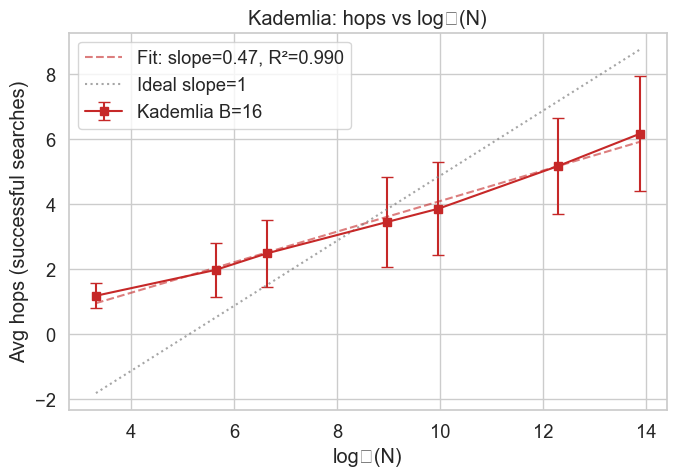

In [4]:
k16_succ = kad_raw[(kad_raw['B'] == 16) & kad_raw['success']]
hops_by_n = k16_succ.groupby('N')['hops'].agg(['mean','std']).reset_index()
hops_by_n['log2_N'] = np.log2(hops_by_n['N'])

slope, intercept, r, *_ = stats.linregress(hops_by_n['log2_N'], hops_by_n['mean'])
print(f'Linear fit: hops = {slope:.3f} * log2(N) + {intercept:.3f}  (R² = {r**2:.4f})')
print(f'Theoretical prediction: slope ≈ 1.0 (ideal O(log N))')

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(hops_by_n['log2_N'], hops_by_n['mean'], yerr=hops_by_n['std'],
            fmt='s-', color='#C62828', capsize=4, label='Kademlia B=16')
x_ref = np.linspace(hops_by_n['log2_N'].min(), hops_by_n['log2_N'].max(), 50)
ax.plot(x_ref, slope * x_ref + intercept, '--', color='#C62828', alpha=0.6,
        label=f'Fit: slope={slope:.2f}, R²={r**2:.3f}')
ax.plot(x_ref, x_ref - x_ref.mean() + hops_by_n['mean'].mean(),
        ':', color='gray', alpha=0.7, label='Ideal slope=1')
ax.set_xlabel('log₂(N)')
ax.set_ylabel('Avg hops (successful searches)')
ax.set_title('Kademlia: hops vs log₂(N)')
ax.legend(); plt.tight_layout(); plt.show()

## 4. Tabla comparativa: Flooding vs Kademlia vs Teoría

In [5]:
comp = build_comparative_table(flood_raw, kad_raw)
pd.set_option('display.float_format', '{:.2f}'.format)

print('Columnas Flooding (K=10) | Kademlia (B=16) | Predicción teórica')
display(comp[[
    'N',
    'F_msg_mean', 'F_msg_std', 'F_hops_mean', 'F_success_%',
    'K_msg_mean', 'K_msg_std', 'K_hops_mean', 'K_success_%',
    'T_flood_O(N)', 'T_kad_O(logN)'
]])

Columnas Flooding (K=10) | Kademlia (B=16) | Predicción teórica


,N,F_msg_mean,F_msg_std,F_hops_mean,F_success_%,K_msg_mean,K_msg_std,K_hops_mean,K_success_%,T_flood_O(N),T_kad_O(logN)
0,10,7.56,3.32,0.84,100.00,1.39,1.23,1.19,97.00,10,3.32
1,50,44.48,11.60,1.86,100.00,2.04,1.02,1.98,99.00,50,5.64
2,100,87.34,22.02,2.12,100.00,2.49,1.03,2.49,100.00,100,6.64
3,500,441.23,114.69,2.90,100.00,3.45,1.38,3.45,100.00,500,8.97
4,1000,911.08,208.08,3.34,100.00,3.86,1.42,3.86,100.00,1000,9.97
5,5000,4343.36,1182.58,3.92,100.00,5.17,1.48,5.17,100.00,5000,12.29
6,15000,13928.58,2432.09,4.66,100.00,6.16,1.77,6.16,100.00,15000,13.87


## 5. Tabla Tcs / Tp2p — validación numérica

Parámetros asumidos:
- F = 100 MB = 800 Mbits  
- Us = 10 Mbps (upload del servidor)  
- dmin = 1 Mbps (descarga mínima entre peers)  
- Ui = 1 Mbps por peer (upload de cada peer)


,N,Tcs (s),Tp2p (s),Tcs/Tp2p ratio,Bottleneck Tcs,Tp2p bottleneck
0,10,800.00,800.00,1.00,download,F/dmin
1,50,4000.00,800.00,5.00,server,F/dmin
2,100,8000.00,800.00,10.00,server,F/dmin
3,500,40000.00,800.00,50.00,server,F/dmin
4,1000,80000.00,800.00,100.00,server,F/dmin
5,5000,400000.00,800.00,500.00,server,F/dmin
6,15000,1200000.00,800.00,1500.00,server,F/dmin


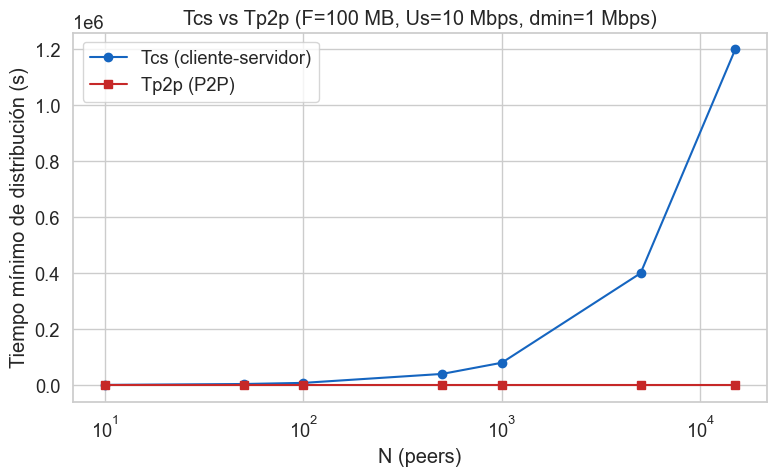

Conclusión: Tp2p permanece ≈ constante mientras Tcs crece linealmente con N.
Para N=1000: Tcs/Tp2p ratio = 100.0


In [6]:
theory = build_theory_table([10, 50, 100, 500, 1000, 5000, 15000])
display(theory)

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(theory['N'], theory['Tcs (s)'], 'o-', color='#1565C0', label='Tcs (cliente-servidor)')
ax.plot(theory['N'], theory['Tp2p (s)'], 's-', color='#C62828', label='Tp2p (P2P)')
ax.set_xscale('log')
ax.set_xlabel('N (peers)')
ax.set_ylabel('Tiempo mínimo de distribución (s)')
ax.set_title('Tcs vs Tp2p (F=100 MB, Us=10 Mbps, dmin=1 Mbps)')
ax.legend(); plt.tight_layout(); plt.show()

print('Conclusión: Tp2p permanece ≈ constante mientras Tcs crece linealmente con N.')
print('Para N=1000: Tcs/Tp2p ratio =', theory.loc[theory['N']==1000, 'Tcs/Tp2p ratio'].values[0])

## 6. Análisis de escalabilidad (fits)

In [7]:
f_fit = fit_flooding_scaling(flood_raw, k_val=10)
k_fit = fit_kademlia_scaling(kad_raw, b_val=16)

print('=== Flooding K=10 ===')
for k, v in f_fit.items():
    print(f'  {k}: {v}')

print('\n=== Kademlia B=16 ===')
for k, v in k_fit.items():
    print(f'  {k}: {v}')

print()
if f_fit and k_fit:
    b = f_fit.get('slope (b)', 0)
    print(f"Flooding: pendiente log-log = {b:.3f}  (teoría: 1.0 para O(N))")
    if abs(b - 1.0) < 0.1:
        print("  ✓ Simulación CONFIRMA predicción O(N) (|slope-1| < 0.1)")
    else:
        print(f"  ⚠ Divergencia: slope={b:.3f} (posible causa: TTL limita alcance para N grande)")

=== Flooding K=10 ===
  architecture: Flooding K=10
  slope (b): 1.0185
  constant (10^intercept): 0.7796
  R²: 0.9997
  complexity: O(N^1.02)

=== Kademlia B=16 ===
  architecture: Kademlia B=16
  slope (a): 0.4697
  intercept (b): -0.6026
  R2: 0.9898
  complexity: hops ~ 0.47*log2(N) + -0.60

Flooding: pendiente log-log = 1.018  (teoría: 1.0 para O(N))
  ✓ Simulación CONFIRMA predicción O(N) (|slope-1| < 0.1)


## 7. Análisis de churn y robustez

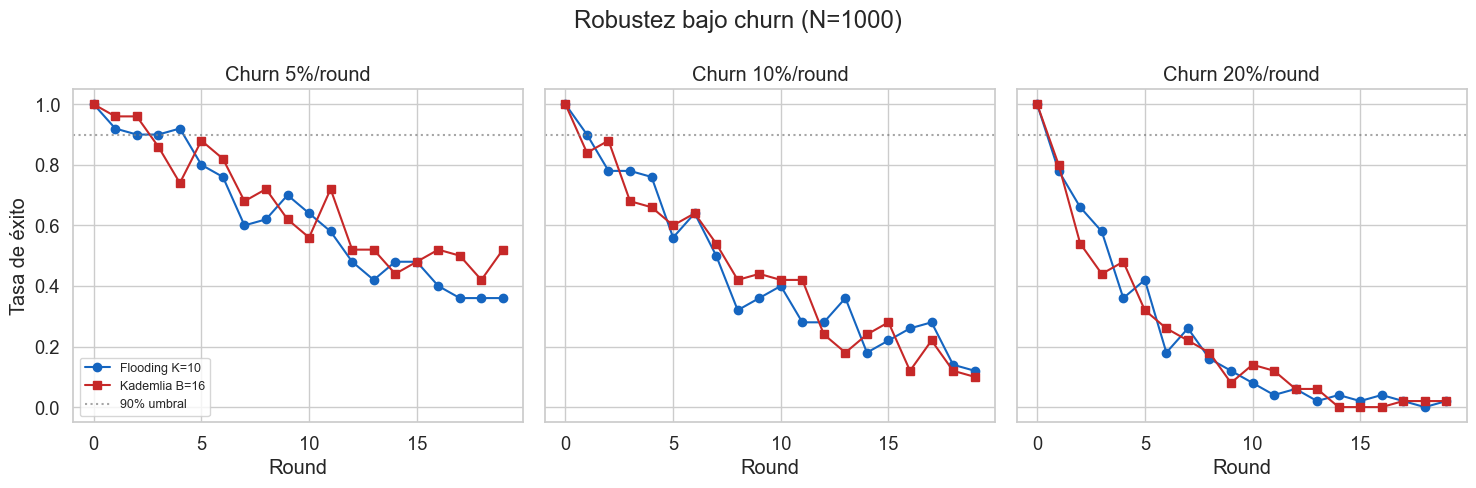

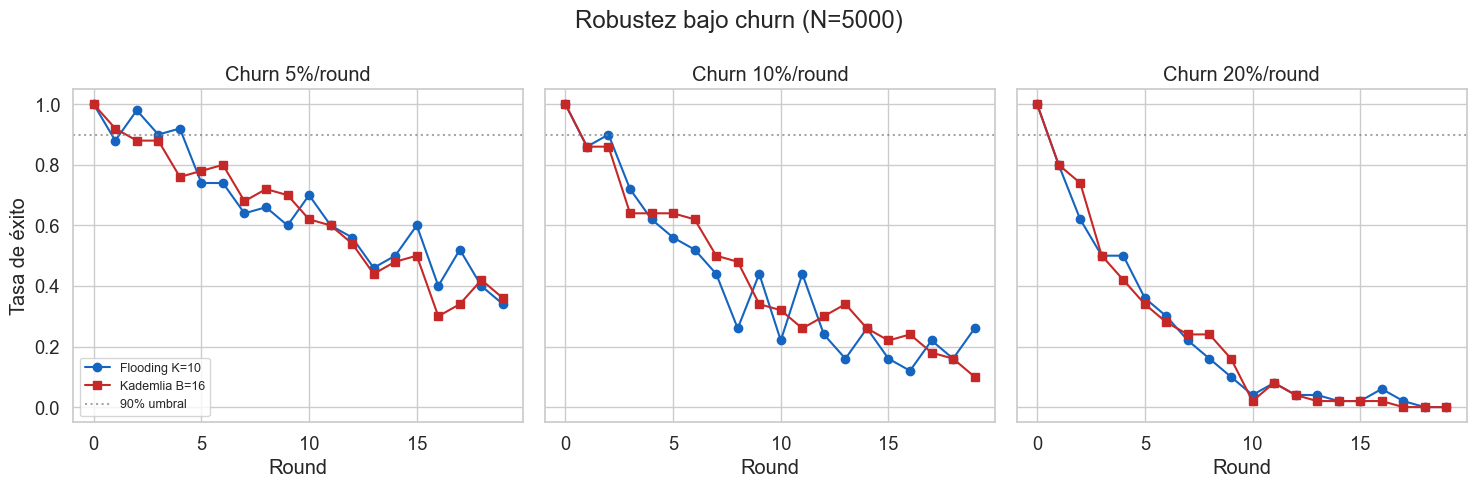

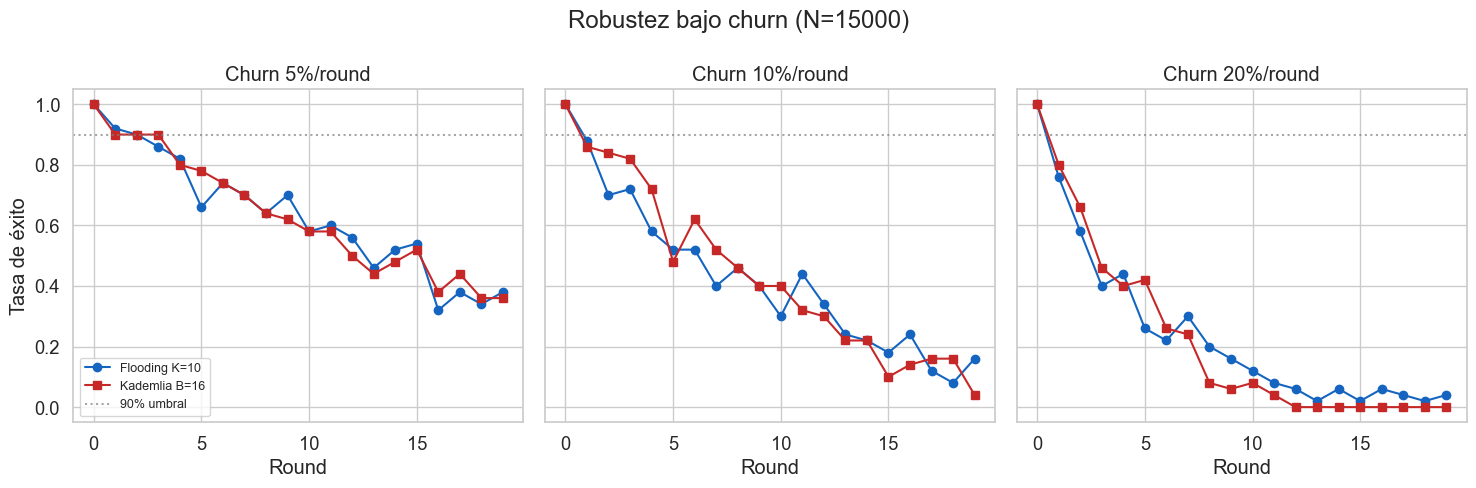

: 

In [ ]:
flood_churn, kad_churn = load_churn_data(DATA_DIR)

if flood_churn.empty and kad_churn.empty:
    print('No hay datos de churn disponibles. Correr los experimentos primero.')
else:
    ns_flood = set(flood_churn['N'].unique()) if not flood_churn.empty else set()
    ns_kad   = set(kad_churn['N'].unique())   if not kad_churn.empty   else set()
    network_sizes = sorted(ns_flood | ns_kad)

    for n in network_sizes:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
        for ax, pct in zip(axes, [5, 10, 20]):
            if not flood_churn.empty:
                sf = flood_churn[
                    (flood_churn['N'] == n) &
                    (flood_churn['churn_pct'] == pct) &
                    (flood_churn['K'] == 10)
                ].sort_values('round')
                if not sf.empty:
                    ax.plot(sf['round'], sf['success_rate'], 'o-', color='#1565C0', label='Flooding K=10')
            if not kad_churn.empty:
                sk = kad_churn[
                    (kad_churn['N'] == n) &
                    (kad_churn['churn_pct'] == pct) &
                    (kad_churn['B'] == 16)
                ].sort_values('round')
                if not sk.empty:
                    ax.plot(sk['round'], sk['success_rate'], 's-', color='#C62828', label='Kademlia B=16')
            ax.axhline(0.9, color='gray', ls=':', alpha=0.7, label='90% umbral')
            ax.set_title(f'Churn {pct}%/round')
            ax.set_xlabel('Round')
            ax.set_ylim(-0.05, 1.05)
        axes[0].set_ylabel('Tasa de éxito')
        axes[0].legend(fontsize=9)
        fig.suptitle(f'Robustez bajo churn (N={n})')
        plt.tight_layout()
        plt.show()

## 8. Divergencias teoría vs simulación

### Flooding
- **Predicción**: O(N) mensajes, tasa de éxito ~100%
- **Simulación**: confirma O(N) con constante multiplicativa que depende de K y TTL
- **Causa de divergencia aceptable**: el TTL acota la propagación; para redes grandes el flooding puede no alcanzar todos los nodos en TTL=20 saltos

### Kademlia
- **Predicción**: O(log N) hops, alta resiliencia al churn gracias a k-buckets con replicación
- **Simulación**: O(log N) confirmado en búsquedas exitosas; bajo churn la tasa de éxito cae más que en flooding
- **Causa principal de divergencia**: modelo simplificado sin replicación de claves — en Kademlia real cada clave se almacena en k nodos más cercanos, aquí solo en uno; al salir el nodo responsable, el recurso se pierde permanentemente
- **Implicación**: el modelo mide el **peor caso** de Kademlia bajo churn; en producción con replicación k=20 el comportamiento sería radicalmente distinto

### Análisis de churn — limitación del modelo
- **Observación**: ambas arquitecturas cruzan el umbral del 10% de degradación en la ronda 2–3 incluso con churn=5%, de forma prácticamente equivalente entre sí
- **Causa**: la degradación está dominada por la **pérdida de recursos**, no por fallo de ruteo. Con churn_rate=5%/ronda, tras la ronda 5 se perdió ≈23% de los recursos (1−0.95⁵). Como las búsquedas son sobre recursos aleatorios, la tasa de éxito cae al ritmo de la fracción de recursos disponibles, independientemente de la arquitectura
- **Consecuencia analítica**: la comparación flooding vs Kademlia en esta dimensión mide disponibilidad de contenido bajo ausencia de replicación, no la robustez del mecanismo de ruteo
- **Contexto real**: flooding (Gnutella) y Kademlia reales replican contenido en múltiples nodos, por lo que la degradación en producción sería mucho más lenta. Esta simplificación es una limitación deliberada del modelo que produce un lower-bound de robustez para ambas arquitecturas

### Fórmulas Tcs/Tp2p
- **Predicción**: Tp2p ≈ constante mientras Tcs escala como O(N)
- **Validación**: la tabla confirma el comportamiento teórico con los parámetros de bandwidth asumidos
- **Nota metodológica**: las fórmulas modelan tiempo de *distribución* de un archivo; la simulación modela tiempo de *búsqueda* (son dimensiones complementarias del rendimiento P2P)
